# 11 — Final Prediction Validation

Produces the final convex hull plots and sublattice occupancy predictions for the complex TCP phases. Generates the main paper figures.

## Prerequisites / Input files
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/results/PREDICTION__*.csv` — prediction CSVs (included in repo)
- `Fe-Mo/validation_data/ValidationFullyCuratedParsedBriefSummary.pkl` — processed validation DFT data (output of nb10)

## Outputs
- Main paper figures in `Fe-Mo/graphs/`



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import os

In [2]:
import shutil
import subprocess


def has_full_texlive():
    required_bins = ("latex", "dvipng", "gs", "kpsewhich")
    if any(shutil.which(binary) is None for binary in required_bins):
        return False

    # Verify key LaTeX files are discoverable in the TeX installation.
    required_files = ("article.cls", "type1cm.sty")
    for tex_file in required_files:
        result = subprocess.run(
            ["kpsewhich", tex_file],
            check=False,
            capture_output=True,
            text=True,
        )
        if result.returncode != 0 or not result.stdout.strip():
            return False

    return True


usetex_enabled = has_full_texlive()
if not usetex_enabled:
    print("TeX Live full feature set not detected; using Matplotlib text rendering.")

plt.rc("text", usetex=usetex_enabled)
plt.rc("font", family="serif", size=24)
plt.rc("xtick", labelsize=18)
plt.rc("ytick", labelsize=18)
plt.rc("axes", labelsize=18)

In [3]:
from ase import Atoms

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
ValidationBS = pd.read_pickle(os.path.join('Fe-Mo', 'validation_data', 'ValidationFullyCuratedParsedBriefSummary.pkl'))

In [6]:
ValidationBS#.head()#.columns

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.0009403500000000001, -0.00018...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.171448,1.000000,0.000000
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,NM,R-AAAAAABAABB,R,VASP_PBE_500_0.125_0.1_NM/FeMo/R/Fe_pv39Mo_sv1...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-471.893007,"[[0.0, 0.0, 0.0], [0.00065508, 0.00039792, 0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006513,0.735849,0.264151
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539000000000003, -0.0001...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108389,0.857143,0.142857
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04232,0.357143,0.642857
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.0008108400000000001, 0.00079078, -0.00207...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120397,0.928571,0.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,NaN,bulk R-BBBBBBBBABB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,232.000374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.400108,0.113208,0.886792
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM,NaN,bulk R-BABBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,248.566042 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.202739,0.150943,0.849057
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM,NaN,bulk P-BBBBBBBBBBAB,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,251.998072 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.144182,0.142857,0.857143
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,NaN,bulk delta-BBBBBBBBABBABB,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,0.164806,0.142857,0.857143


In [7]:
prediction_data_files = glob.glob('Fe-Mo/results/PREDICTION__*')

In [8]:
prediction_data_files

['Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific_MAG=1.csv',
 'Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific_1.csv',
 'Fe-Mo/results/PREDICTION__delta__SOAP_specific_small_specific.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321_MAG=1.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321_1.csv',
 'Fe-Mo/results/PREDICTION__delta__ACE_lmax=321.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16_MAG=1.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16_1.csv',
 'Fe-Mo/results/PREDICTION__delta__0.7dprojections_0.5os_16.csv',
 'Fe-Mo/results/PREDICTION__R__SOAP_specific_small_specific_MAG=1.csv',
 'Fe-Mo/results/PREDICTION__R__SOAP_specific_small_specific_MAG=0.csv',
 'Fe-Mo/results/PREDICTION__R__SOAP_specific_small_spe

In [9]:
PredictionValues = {}

In [10]:
import re as _re

def _normalize_index(idx):
    """Strip sublattice suffix from pure-element entries (all same letter).
    e.g. Fe_pv56.P-AAAAAAAAAAAA.NM -> Fe_pv56.P.NM"""
    def _strip(name):
        m = _re.match(r'(.+\.[A-Za-z0-9_]+)-([A-Z]+)(\..+)', name)
        if m and len(set(m.group(2))) == 1:
            return m.group(1) + m.group(3)
        return name
    return idx.map(_strip)

for file in prediction_data_files:
    if 'old' in file or file.endswith('_1.csv') or '_MAG=' in file:
        continue
    label, phase, model_with_params = file.replace('.csv','').split('__')
    df = pd.read_csv(file, header=0, index_col=0)
    df.index = _normalize_index(df.index)
    PredictionValues[(model_with_params, phase)] = df

# comparisons

In [11]:
def get_confidence_intervals (regression_model, x, y, n_bootstraps = 1000 ):
    bootstrapped_predictions = np.empty((n_bootstraps, len(x)))
    for i in range(n_bootstraps):
        # Resample the data with replacement
        x_resampled, y_resampled = resample(x, y)
        # Fit the model to the resampled data
        regression_model.fit(x_resampled.reshape(-1, 1), y_resampled)
        # Predict
        bootstrapped_predictions[i] = regression_model.predict(x.reshape(-1, 1))
        lower_ci = np.percentile(bootstrapped_predictions, 2.5, axis=0)
        upper_ci = np.percentile(bootstrapped_predictions, 97.5, axis=0)
    return lower_ci, upper_ci

In [12]:
def plot_with_ci(ytrue, ypred, ax = None):
    sorter = ytrue.values.argsort()
    regressor = LinearRegression()
    regressor.fit(ytrue.values.reshape(-1,1), ypred.values.reshape(-1,1))
    x_y_y = regressor.predict(ytrue.values.reshape(-1,1))
    lower_ci, upper_ci = get_confidence_intervals(LinearRegression(), ytrue.values.astype(float), ypred.values.astype(float))
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(ytrue.values, x_y_y.ravel(), color='tab:blue')#, upper_ci)
    ax.fill_between(ytrue.values.astype(float)[sorter], lower_ci[sorter], upper_ci[sorter], alpha=0.5, color='tab:orange')
    ax.scatter(ytrue, ypred, color='brown', s=60, ec='k')
    return ax

In [13]:
def get_model_position(modelname):
    if 'projections' in modelname:
        return 0
    elif 'ACE' in modelname:
        return 1
    elif 'SOAP' in modelname:
        return 2

In [14]:
phase_position = {'R': 0, 'P' : 2, 'M': 1, 'delta': 3}

In [15]:
phase_label = {'R': '$R$', 'P': '$P$', 'M': '$M$', 'delta': r'$\delta$'}

In [16]:
rmse_tag = {(0,0): 'rmse = '}

In [17]:
plt.rcParams['figure.figsize']

[6.4, 4.8]

SOAP_specific_small delta EF_nmhcp__SOAP_specific_small


ACE delta EF_nmhcp__ACE


0.7dprojections_0.5os delta EF_nmhcp__0.7dprojections_0.5os


SOAP_specific_small R EF_nmhcp__SOAP_specific_small


ACE R EF_nmhcp__ACE


...

ACE P EF_nmhcp__ACE


0.7dprojections_0.5os P EF_nmhcp__0.7dprojections_0.5os


SOAP_specific_small M EF_nmhcp__SOAP_specific_small


ACE M EF_nmhcp__ACE


0.7dprojections_0.5os M EF_nmhcp__0.7dprojections_0.5os


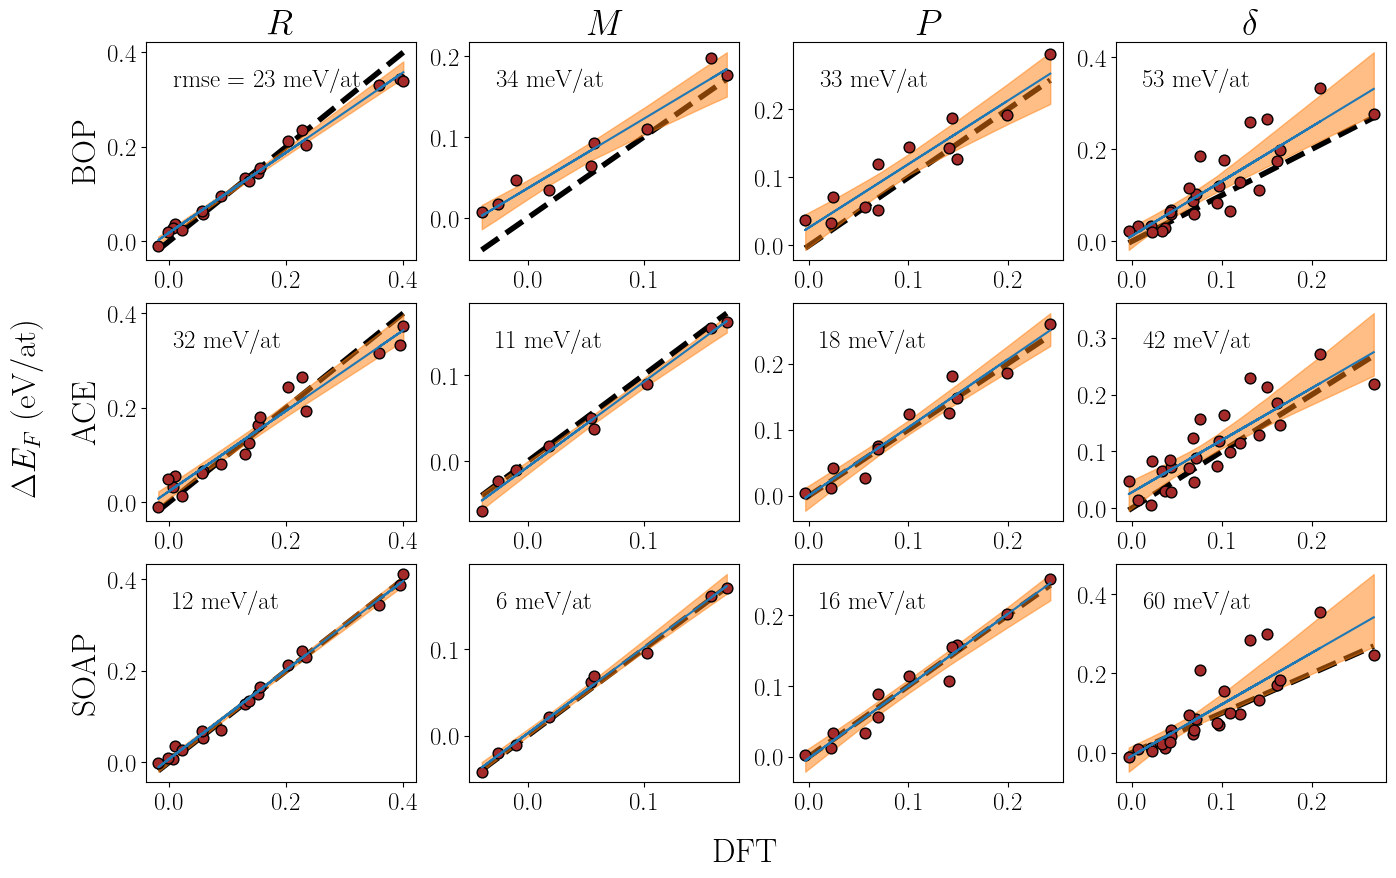

In [18]:
figsize = plt.rcParams['figure.figsize']
fig, ax = plt.subplots(3, len(phase_position), figsize=(figsize[0]*2.5, figsize[1]*2))
rmse = {}
for (model, phase), prediction_values in PredictionValues.items():
    model_name = model.replace('_16','').replace('_lmax=321','').replace('_small_specific','_small')
    target_name = f'EF_nmhcp__{model_name}'
    print(model_name, phase, target_name)
    this_validation_data = ValidationBS.query('Phase == "'+phase+'"')['EF']
    this_validation_data = this_validation_data.loc[~this_validation_data.index.duplicated(keep='first')]
    predictions_with_validation = prediction_values.index.intersection(this_validation_data.index)
    if len(predictions_with_validation) == 0 or target_name not in prediction_values.columns:
        continue
    ytrue = this_validation_data[predictions_with_validation]
    ypred = prediction_values[target_name][predictions_with_validation]
    rmse[(model, phase)] = np.sqrt(mean_squared_error(ytrue, ypred))
    this_rmse = rmse[(model, phase)]
    I = get_model_position(model_name)
    J = phase_position[phase]
    ax[I,J] = plot_with_ci(ytrue, ypred, ax=ax[I,J])
    this_rmse_label = rf'{rmse_tag.get((I,J), "")}{this_rmse*1000 :.0f} meV/at'
    ax[I,J].annotate(this_rmse_label,(0.1, 0.8), xycoords='axes fraction', fontsize = 18)
    if I == 0:
        ax[I,J].set_title(phase_label.get(phase), fontsize = 26)
    ax[I,J].plot([ytrue.min(), ytrue.max()], [ytrue.min(), ytrue.max()], '--k', linewidth=4, zorder = -10)
ylabel_bop =ax[get_model_position('projections'),0].set_ylabel('BOP', fontsize=24)
ylabel_ACE =ax[get_model_position('ACE'), 0].set_ylabel('ACE', fontsize=24)
ylabel_SOAP =ax[get_model_position('SOAP'), 0].set_ylabel('SOAP', fontsize=24)
fig.subplots_adjust(wspace=0.2, hspace=0.2)
fig.supxlabel('DFT', fontsize=24, y=0.02)
fig.supylabel('$\Delta E_F$ (eV/at)', fontsize=24, x=0.04)
fig.savefig('Fe-Mo/graphs/Figure_Fe-Mo_Predictions_Validation.pdf')

# DFT convex hulls from Validation calculations

In [19]:
from Tools.DatasetTools.Tools import Plotting

In [20]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [21]:
P = Plotting()

In [22]:
ValidationBS.Phase.value_counts()

Phase
delta    28
R        20
P        12
M         9
Name: count, dtype: int64

In [23]:
BS = BS.rename(columns = {'Fe_pv': 'x_Fe', 'Mo_sv': 'x_Mo', 'EF_nmhcp': 'EF'})

In [24]:
# NOTE: 'phasedata' and 'phase' are defined in the loop below (cell 25).
# This standalone cell was an interactive debug snippet; see the full loop below.

In [25]:
# NOTE: 'phasedata' and 'phase' are defined in the loop below (cell 25).
# This standalone cell was an interactive debug snippet; see the full loop below.

In [26]:
# NOTE: CHULLS_DFT_V is defined in the DFT convex hull loop.
# This standalone debug cell requires that loop to have run first.
# Skipped for publication.
pass

# save DFT chulls

In [27]:
# NOTE: CHULLS_DFT_V is defined in the DFT convex hull loop.
# This standalone debug cell requires that loop to have run first.
# Skipped for publication.
pass

# not sure what i do here.

In [28]:
for (model, phase), prediction_values in PredictionValues.items():
    break

In [29]:
sorted_validation = ValidationBS.query(f'Phase == "{phase}"').sort_values(by='x_Fe')

In [30]:
validated_samples = prediction_values.index.intersection(sorted_validation.index)

In [31]:
prediction_values.loc[validated_samples]

,EF_nmhcp__SOAP_specific_small,vote_0,vote_1,vote_2,vote_3,vote_4,vote_5,vote_6,vote_7,vote_8,vote_9,std_votes
Fe_pv56.delta.NM,0.169512,0.175369,0.161144,0.174716,0.165783,0.162553,0.170536,0.162895,0.171256,0.185834,0.165030,0.007660
Fe_pv48Mo_sv8.delta-AAAAAABAAAAABA.NM,0.156388,0.150791,0.158876,0.160363,0.146885,0.159569,0.147641,0.149251,0.165220,0.163931,0.161349,0.006998
Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM,0.283507,0.295499,0.279818,0.265632,0.277871,0.267311,0.280460,0.269023,0.293407,0.298596,0.307450,0.014488
Fe_pv40Mo_sv16.delta-AAAAAABBABAAAB.NM,0.208582,0.203433,0.219193,0.192662,0.220673,0.211817,0.185429,0.202089,0.217343,0.211503,0.221678,0.012402
Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM,0.300318,0.303061,0.297367,0.280638,0.303391,0.290369,0.286940,0.289817,0.300780,0.308798,0.342020,0.017037
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM,0.354011,0.364590,0.336895,0.349088,0.359676,0.330869,0.339162,0.347519,0.365412,0.362723,0.384177,0.016245
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,0.098060,0.109965,0.083939,0.118991,0.079062,0.105182,0.085953,0.095527,0.082447,0.123071,0.096466,0.015690
Fe_pv48Mo_sv8.delta-AABABAAAAAAAAA.NM,0.070263,0.069470,0.056656,0.092368,0.053957,0.084563,0.044638,0.069028,0.066151,0.097926,0.067877,0.016967
Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM,0.047474,0.038634,0.035889,0.075874,0.025713,0.067157,0.019594,0.042591,0.048971,0.074480,0.045839,0.019480
Fe_pv52Mo_sv4.delta-BAAAAAAAAAAAAA.NM,0.131927,0.131858,0.136475,0.114784,0.131244,0.128755,0.141709,0.139089,0.143624,0.134381,0.117356,0.009587


In [32]:
# NOTE: debug cell — column name depends on loop variable. Skipped.
pass

In [33]:
ValidationBS.loc[validated_samples]['x_Fe']

Fe_pv56.delta.NM                          1.000000
Fe_pv48Mo_sv8.delta-AAAAAABAAAAABA.NM     0.857143
Fe_pv36Mo_sv20.delta-AAAAAABAABBABB.NM    0.642857
Fe_pv40Mo_sv16.delta-AAAAAABBABAAAB.NM    0.714286
Fe_pv32Mo_sv24.delta-AAAAAABBABBABB.NM    0.571429
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    0.500000
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM     0.928571
Fe_pv48Mo_sv8.delta-AABABAAAAAAAAA.NM     0.857143
Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM    0.785714
Fe_pv52Mo_sv4.delta-BAAAAAAAAAAAAA.NM     0.928571
Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM     0.857143
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM     0.857143
Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM    0.785714
Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM    0.642857
Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM    0.571429
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM    0.500000
Fe_pv36Mo_sv20.delta-BBBBBAAAAAAAAA.NM    0.642857
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    0.428571
Fe_pv28Mo_sv28.delta-BBBBBBBAAAAAAA.NM    0.500000
Fe_pv24Mo_sv32.delta-BBBBBBBBAA